In [1]:
import re
import os
import pathlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import gridspec
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme(style="darkgrid")

# Root of the project
project_dir = pathlib.Path().resolve().parent

# Directory containing experiment results
results_dir = (pathlib.Path(project_dir) / "results").resolve()

# Directory for tidied data (output directory)
data_dir = (pathlib.Path(project_dir) / "data").resolve()

# Directory to store all plots
plot_dir = (pathlib.Path(project_dir) / "plots").resolve()



# Experiment constants
exp_name = "04_grpc_max_throughput"
file_prefix = "exp-04"

In [2]:
"""Load and prepare the dataset

resource_df -> CPU/Mem utilization for experiments
fortio_df -> Load test results from fortio
"""

# df = pd.read_feather(data_dir / "resource_results.feather")
df = pd.read_feather(data_dir / "fortio_results.feather")

df = df[df["experiment"] == exp_name]
df = df.drop("actual_qps", axis=1)
df = df.explode("latency")
df = df.reset_index(drop=True)
df = df.astype({
    "experiment": "category",
    "mesh": "category",
    "requested_qps": "category",
    "payload": "category",
    "protocol": "category",
    "latency": np.float64,
})

df = df.sort_values("mesh", ascending=True)

df.head()

,experiment,mesh,requested_qps,protocol,payload,latency
6372468,04_grpc_max_throughput,Baseline,MAX,grpc,0,0.141177
7528438,04_grpc_max_throughput,Baseline,MAX,grpc,0,0.139077
7528439,04_grpc_max_throughput,Baseline,MAX,grpc,0,0.132978
7528440,04_grpc_max_throughput,Baseline,MAX,grpc,0,0.102914
7528441,04_grpc_max_throughput,Baseline,MAX,grpc,0,0.109719


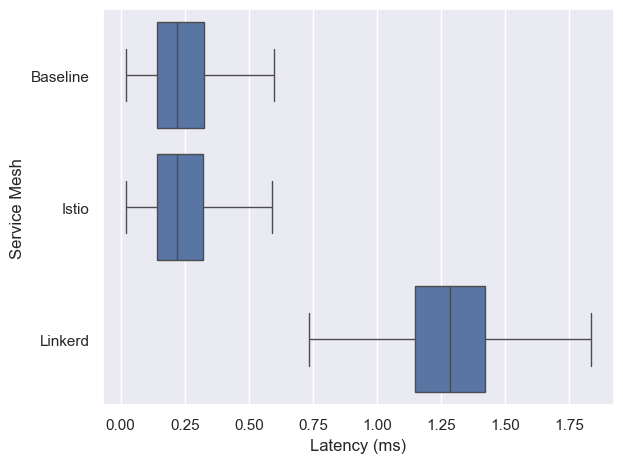

In [3]:
"""
PLOT: Boxplot latency by mesh
Desc: Show 25p med 50p latencies
"""

file_name = f"{file_prefix}-latency.pdf"

fig, ax = plt.subplots()
ax = sns.boxplot(data=df, x="latency", y="mesh", showfliers=False)

# Labels
ax.set_ylabel("Service Mesh")
ax.set_xlabel("Latency (ms)")

# ax.set_xscale("log")

fig.tight_layout()
fig.savefig(plot_dir / file_name)

In [4]:
# The quantiles to plot
quantiles = [
    0.99,
    0.999,
    0.9999
]

data = df.groupby("mesh")["latency"].quantile(quantiles)
data = data.reset_index().rename(columns={"level_1": "percentile"})
data["percentile"] *= 100
data.head()

,mesh,percentile,latency
0,Baseline,99.00,2.499807
1,Baseline,99.90,3.693397
2,Baseline,99.99,5.363835
3,Istio,99.00,2.491586
4,Istio,99.90,3.677934


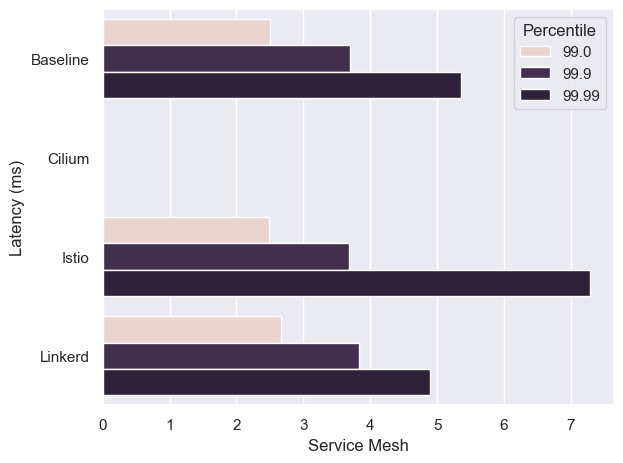

In [5]:

"""
PLOT: Tail End Latencies
"""

# Plotting
file_name = f"{file_prefix}-tail-latencies.pdf"

fig, ax = plt.subplots()
ax = sns.barplot(data=data, y="mesh", x="latency", order=["Baseline", "Cilium", "Istio", "Linkerd"], hue="percentile")

# Scaling
# ax.set_xscale()
# ax.set_yscale()

# Limits
# ax.set_xscale()
# ax.set_yscale()

# Labels
ax.set_xlabel("Service Mesh")
ax.set_ylabel("Latency (ms)")

# ax.legend(labels=["p99", "p99.9", "p99.99"], title= "Percentiles")
ax.legend(title= "Percentile")

fig.tight_layout()
fig.savefig(plot_dir / file_name)

In [6]:
data = df[df["mesh"] == "Istio"]
qt = data["latency"].quantile(.999)
data.loc[data["latency"] > qt]


,experiment,mesh,requested_qps,protocol,payload,latency
5646172,04_grpc_max_throughput,Istio,MAX,grpc,0,3.916702
5645827,04_grpc_max_throughput,Istio,MAX,grpc,0,3.815761
5645825,04_grpc_max_throughput,Istio,MAX,grpc,0,3.972192
5645823,04_grpc_max_throughput,Istio,MAX,grpc,0,3.724467
5645821,04_grpc_max_throughput,Istio,MAX,grpc,0,3.844006
...,...,...,...,...,...,...
5648374,04_grpc_max_throughput,Istio,MAX,grpc,0,3.897381
5648372,04_grpc_max_throughput,Istio,MAX,grpc,0,3.765746
5648371,04_grpc_max_throughput,Istio,MAX,grpc,0,3.698766
5648370,04_grpc_max_throughput,Istio,MAX,grpc,0,3.711156


In [7]:
df["latency"].quantile(.999)

np.float64(3.7125041150424827)